# Step 2 - Train sampled-curve functional classifier on Stratum 1, adapt with Stratum 2

This follows `02_train_nn_test_stratum2.ipynb`, but uses the memory-safe sampled-curve k-nearest-neighbor functional classifier from `02_train_fdc.ipynb`. The Stratum 2 fine-tune split is added to the k-NN reference set, then the classifier is evaluated on the held-out Stratum 2 rows.


In [1]:
import json
import re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier

try:
    from skfda.representation.grid import FDataGrid
except ImportError as exc:
    raise ImportError(
        "This notebook needs scikit-fda for FDataGrid metadata/inspection. "
        "Install it with `pip install scikit-fda` or add `scikit-fda` to requirements.txt."
    ) from exc


REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

DATA_PREP = REPO_ROOT / "data" / "prepared"
MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

train_file = DATA_PREP / "S1_point_all_10d_10m_20180101-20180731_Stratum1_VV-VH.csv"
test_file = DATA_PREP / "S1_point_all_10d_10m_20180101-20180731_Stratum2_VV-VH.csv"
classes_file = DATA_PREP / "LUCAS_2018_Copernicus_attributes_cropmap_level1-2_FROM_EXPORTS.csv"

# Sampled-curve k-NN classifier settings.
N_NEIGHBORS = 5
WEIGHTS = "distance"
TEST_SIZE = 0.25
RANDOM_STATE = 42
STRATUM2_FINE_TUNE_FRACTION = 0.10
PREDICT_BATCH_SIZE = 20_000

# Set these to integers for faster experiments on very large files.
N_TRAIN_MAX = None
N_VAL_MAX = None
N_STRATUM2_FINE_TUNE_MAX = None
N_STRATUM2_TEST_MAX = None

assert train_file.exists(), f"Missing training dataset file: {train_file}"
assert test_file.exists(), f"Missing Stratum 2 test dataset file: {test_file}"
assert classes_file.exists(), f"Missing classes file: {classes_file}"

print("Using train_file:", train_file)
print("Using test_file:", test_file)
print("Using classes_file:", classes_file)
print("Stratum 2 fine-tune fraction:", STRATUM2_FINE_TUNE_FRACTION)
print("Saving outputs to:", MODELS_DIR)


Using train_file: /home/zhenisbek/RS/eucropmap-reprod-kz/data/prepared/S1_point_all_10d_10m_20180101-20180731_Stratum1_VV-VH.csv
Using test_file: /home/zhenisbek/RS/eucropmap-reprod-kz/data/prepared/S1_point_all_10d_10m_20180101-20180731_Stratum2_VV-VH.csv
Using classes_file: /home/zhenisbek/RS/eucropmap-reprod-kz/data/prepared/LUCAS_2018_Copernicus_attributes_cropmap_level1-2_FROM_EXPORTS.csv
Stratum 2 fine-tune fraction: 0.1
Saving outputs to: /home/zhenisbek/RS/eucropmap-reprod-kz/models


In [2]:
class_table = pd.read_csv(classes_file)
print(class_table)


       POINT_ID  stratum  LC1   LU1  level_1  level_2
0      47242864        1  B11  U111      200      211
1      47322804        1  B11  U111      200      211
2      47602810        1  B11  U111      200      211
3      47622814        1  B11  U111      200      211
4      47642818        1  B11  U111      200      211
...         ...      ...  ...   ...      ...      ...
62847  43262410        2  E20  U111      500      500
62848  43602380        2  E20  U111      500      500
62849  42842416        2  E30  U111      500      500
62850  43242398        2  E30  U111      500      500
62851  43482400        2  E30  U111      500      500

[62852 rows x 6 columns]


In [3]:
classes_L1 = class_table["level_1"].dropna().unique().tolist()
classes_L2 = class_table["level_2"].dropna().unique().tolist()

train_df = pd.read_csv(train_file, dtype={"level_1": int, "level_2": int})
test_df = pd.read_csv(test_file, dtype={"level_1": int, "level_2": int})

print(f"Loaded Stratum 1 training dataset with shape {train_df.shape}")
print(f"Loaded Stratum 2 test dataset with shape {test_df.shape}")


Loaded Stratum 1 training dataset with shape (1743815, 46)
Loaded Stratum 2 test dataset with shape (1367821, 46)


In [4]:
# Official Level-2 crop set.
L2_official = {211, 212, 213, 214, 215, 216, 217, 218, 219, 221, 222, 223, 230, 231, 232, 233, 240, 250, 290}
classes_L2 = [c for c in classes_L2 if c in L2_official]

train_df["Classif"] = train_df["level_2"]
test_df["Classif"] = test_df["level_2"]

if classes_L2:
    train_df = train_df[train_df["Classif"].isin(classes_L2)]
    test_df = test_df[test_df["Classif"].isin(classes_L2)]

# Keep only crop classes present in both strata so the external test only uses labels the model can predict.
common_classes = sorted(set(train_df["Classif"]).intersection(set(test_df["Classif"])))
train_df = train_df[train_df["Classif"].isin(common_classes)].copy()
test_df = test_df[test_df["Classif"].isin(common_classes)].copy()

print(f"Classes in level_1: {classes_L1}")
print(f"Shared level_2 crop classes: {common_classes}")
print(f"Stratum 1 after filtering to shared crop classes: {train_df.shape}")
print(f"Stratum 2 after filtering to shared crop classes: {test_df.shape}")
print("Stratum 1 class distribution:")
print(train_df["Classif"].value_counts().sort_index())
print("Stratum 2 class distribution:")
print(test_df["Classif"].value_counts().sort_index())


Classes in level_1: [200, 500, 300, 600, 100]
Shared level_2 crop classes: [211, 212, 213, 214, 215, 216, 218, 219, 221, 222, 223, 230, 231, 232, 233, 240, 250, 290]
Stratum 1 after filtering to shared crop classes: (604610, 47)
Stratum 2 after filtering to shared crop classes: (447227, 47)
Stratum 1 class distribution:
Classif
211    195821
212      4711
213     89215
214     31153
215     24001
216     69089
218     16124
219      3446
221     14620
222     22901
223      3780
230      6360
231      1975
232     53663
233      1744
240     18351
250     23366
290     24290
Name: count, dtype: int64
Stratum 2 class distribution:
Classif
211    101285
212     25474
213     58646
214      5366
215     11248
216     64717
218      3711
219      1668
221      2040
222      1991
223      1498
230      6611
231     37921
232     19043
233      5833
240     17760
250     40206
290     42209
Name: count, dtype: int64


In [5]:
def dated_band_columns(columns, prefix):
    pattern = re.compile(rf"^{prefix}_(20180[1-7]\d{{2}})$")
    dated = []
    for col in columns:
        match = pattern.match(col)
        if match:
            dated.append((match.group(1), col))
    return dict(sorted(dated))


train_vh_by_date = dated_band_columns(train_df.columns, "VH")
train_vv_by_date = dated_band_columns(train_df.columns, "VV")
test_vh_by_date = dated_band_columns(test_df.columns, "VH")
test_vv_by_date = dated_band_columns(test_df.columns, "VV")

dates = sorted(
    set(train_vh_by_date)
    .intersection(train_vv_by_date)
    .intersection(test_vh_by_date)
    .intersection(test_vv_by_date)
)

if not dates:
    raise ValueError("No matching VH/VV dated Sentinel-1 columns found in both strata")

vh_cols = [train_vh_by_date[date] for date in dates]
vv_cols = [train_vv_by_date[date] for date in dates]
test_vh_cols = [test_vh_by_date[date] for date in dates]
test_vv_cols = [test_vv_by_date[date] for date in dates]
feature_names = [name for pair in zip(vh_cols, vv_cols) for name in pair]

if vh_cols != test_vh_cols or vv_cols != test_vv_cols:
    raise ValueError("Stratum 1 and Stratum 2 VH/VV feature names do not match for the shared dates")

date_index = pd.to_datetime(dates, format="%Y%m%d")
grid_points = (date_index - date_index.min()).days.to_numpy(dtype=float)


def curves_from_df(df):
    return np.stack(
        [
            df[vh_cols].to_numpy(dtype=np.float32),
            df[vv_cols].to_numpy(dtype=np.float32),
        ],
        axis=-1,
    )


X_curves = curves_from_df(train_df)
y = train_df["Classif"].to_numpy()
X_stratum2_curves = curves_from_df(test_df)
y_stratum2 = test_df["Classif"].to_numpy()

feat_path = MODELS_DIR / "FDC_feature_names_train_stratum1_finetune_stratum2.json"
with open(feat_path, "w") as f:
    json.dump(
        {
            "dates": dates,
            "grid_points_days_since_first_date": grid_points.tolist(),
            "vh_cols": vh_cols,
            "vv_cols": vv_cols,
            "feature_names_interleaved": feature_names,
            "codomain_channels": ["VH", "VV"],
        },
        f,
        indent=2,
    )

print(f"Stratum 1 functional data tensor shape: {X_curves.shape}")
print(f"Stratum 2 functional data tensor shape: {X_stratum2_curves.shape}")
print(f"Using {len(dates)} dates from {dates[0]} to {dates[-1]}")
print(f"Saved functional feature metadata to {feat_path}")


Stratum 1 functional data tensor shape: (604610, 21, 2)
Stratum 2 functional data tensor shape: (447227, 21, 2)
Using 21 dates from 20180101 to 20180720
Saved functional feature metadata to /home/zhenisbek/RS/eucropmap-reprod-kz/models/FDC_feature_names_train_stratum1_finetune_stratum2.json


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_curves, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

X_stratum2_finetune, X_stratum2_test, y_stratum2_finetune, y_stratum2_test = train_test_split(
    X_stratum2_curves,
    y_stratum2,
    train_size=STRATUM2_FINE_TUNE_FRACTION,
    stratify=y_stratum2,
    random_state=RANDOM_STATE,
)

rng = np.random.default_rng(RANDOM_STATE)
if N_TRAIN_MAX is not None and len(X_train) > N_TRAIN_MAX:
    train_idx = rng.choice(len(X_train), size=N_TRAIN_MAX, replace=False)
    X_train = X_train[train_idx]
    y_train = y_train[train_idx]

if N_VAL_MAX is not None and len(X_val) > N_VAL_MAX:
    val_idx = rng.choice(len(X_val), size=N_VAL_MAX, replace=False)
    X_val = X_val[val_idx]
    y_val = y_val[val_idx]

if N_STRATUM2_FINE_TUNE_MAX is not None and len(X_stratum2_finetune) > N_STRATUM2_FINE_TUNE_MAX:
    finetune_idx = rng.choice(len(X_stratum2_finetune), size=N_STRATUM2_FINE_TUNE_MAX, replace=False)
    X_stratum2_finetune = X_stratum2_finetune[finetune_idx]
    y_stratum2_finetune = y_stratum2_finetune[finetune_idx]

if N_STRATUM2_TEST_MAX is not None and len(X_stratum2_test) > N_STRATUM2_TEST_MAX:
    test_idx = rng.choice(len(X_stratum2_test), size=N_STRATUM2_TEST_MAX, replace=False)
    X_stratum2_test = X_stratum2_test[test_idx]
    y_stratum2_test = y_stratum2_test[test_idx]

n_dates = X_train.shape[1]
n_channels = X_train.shape[2]

scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train.reshape(len(X_train), -1))
X_val_flat = scaler.transform(X_val.reshape(len(X_val), -1))
X_stratum2_finetune_flat = scaler.transform(X_stratum2_finetune.reshape(len(X_stratum2_finetune), -1))
X_stratum2_test_flat = scaler.transform(X_stratum2_test.reshape(len(X_stratum2_test), -1))

X_knn_reference_flat = np.vstack([X_train_flat, X_stratum2_finetune_flat])
y_knn_reference = np.concatenate([y_train, y_stratum2_finetune])

X_train_scaled = X_train_flat.reshape(-1, n_dates, n_channels)
X_val_scaled = X_val_flat.reshape(-1, n_dates, n_channels)
X_stratum2_finetune_scaled = X_stratum2_finetune_flat.reshape(-1, n_dates, n_channels)
X_stratum2_test_scaled = X_stratum2_test_flat.reshape(-1, n_dates, n_channels)

fd_train = FDataGrid(data_matrix=X_train_scaled, grid_points=grid_points)
fd_val = FDataGrid(data_matrix=X_val_scaled, grid_points=grid_points)
fd_stratum2_finetune = FDataGrid(data_matrix=X_stratum2_finetune_scaled, grid_points=grid_points)
fd_stratum2_test = FDataGrid(data_matrix=X_stratum2_test_scaled, grid_points=grid_points)

classes = np.array(common_classes)

print("Train functional data:", fd_train)
print("Validation functional data:", fd_val)
print("Stratum 2 fine-tune functional data:", fd_stratum2_finetune)
print("Stratum 2 held-out test functional data:", fd_stratum2_test)
print("Classes:", classes)
print("Flat Stratum 1 train matrix shape:", X_train_flat.shape)
print("Flat Stratum 2 fine-tune matrix shape:", X_stratum2_finetune_flat.shape)
print("Flat k-NN reference matrix shape:", X_knn_reference_flat.shape)
print("Flat validation matrix shape:", X_val_flat.shape)
print("Flat Stratum 2 held-out test matrix shape:", X_stratum2_test_flat.shape)
print("Stratum 2 fine-tune class distribution:")
print(pd.Series(y_stratum2_finetune).value_counts().sort_index())
print("Stratum 2 held-out test class distribution:")
print(pd.Series(y_stratum2_test).value_counts().sort_index())


Train functional data: Data set:    [[[ 1.4241356   1.3762485 ]
  [ 1.828561    2.0984385 ]
  [ 1.3821146   0.9494613 ]
  ...
  [ 1.2344142   2.1557844 ]
  [ 1.0282906   1.7030245 ]
  [ 1.3679888   1.8217258 ]]

 [[-0.3707917   1.4671148 ]
  [ 0.12166294  1.6785934 ]
  [ 1.311791    1.4510093 ]
  ...
  [ 0.9071806   1.1049998 ]
  [ 0.44197506  1.2523266 ]
  [ 1.455182    1.7476879 ]]

 [[ 0.9544374   0.618162  ]
  [ 1.413507    0.9329698 ]
  [ 1.1778396   1.1021475 ]
  ...
  [ 1.902745    1.3346562 ]
  [ 0.39332655  0.14382452]
  [-0.47879988 -0.40585074]]

 ...

 [[-0.8337272  -1.8897597 ]
  [-0.15237862 -1.4223809 ]
  [-0.55621517 -1.9337416 ]
  ...
  [ 0.27759957 -0.08456423]
  [ 0.36794165  0.4330545 ]
  [ 0.937197   -1.2745911 ]]

 [[ 0.01986951 -0.24105792]
  [ 0.05021473 -0.3488657 ]
  [ 0.12531587 -0.39522937]
  ...
  [-0.400905   -0.9160692 ]
  [-1.2156793  -0.65007323]
  [-1.3428534  -0.36723566]]

 [[ 0.30131188 -0.06562986]
  [ 0.11807578  0.11647288]
  [-0.42670155  0.2529

In [7]:
fdc = KNeighborsClassifier(
    n_neighbors=N_NEIGHBORS,
    weights=WEIGHTS,
    algorithm="brute",
    metric="euclidean",
    n_jobs=-1,
)

print("Training sampled-curve k-NN classifier on Stratum 1 plus Stratum 2 fine-tune rows...")
fdc.fit(X_knn_reference_flat, y_knn_reference)
print("Sampled-curve k-NN classifier training completed.")


Training sampled-curve k-NN classifier on Stratum 1 plus Stratum 2 fine-tune rows...
Sampled-curve k-NN classifier training completed.


In [8]:
model_path = MODELS_DIR / "FDC_knn_train_stratum1_finetune_stratum2.joblib"

joblib.dump(
    {
        "classifier": fdc,
        "scaler": scaler,
        "classes": classes,
        "dates": dates,
        "grid_points": grid_points,
        "vh_cols": vh_cols,
        "vv_cols": vv_cols,
        "feature_names_interleaved": feature_names,
        "codomain_channels": ["VH", "VV"],
        "config": {
            "n_neighbors": N_NEIGHBORS,
            "weights": WEIGHTS,
            "test_size": TEST_SIZE,
            "random_state": RANDOM_STATE,
            "stratum2_fine_tune_fraction": STRATUM2_FINE_TUNE_FRACTION,
            "n_train_max": N_TRAIN_MAX,
            "n_val_max": N_VAL_MAX,
            "n_stratum2_fine_tune_max": N_STRATUM2_FINE_TUNE_MAX,
            "n_stratum2_test_max": N_STRATUM2_TEST_MAX,
            "predict_batch_size": PREDICT_BATCH_SIZE,
            "algorithm": "brute",
            "metric": "euclidean",
            "input_shape": "flattened standardized n_dates x n_channels sampled curves",
            "reference_set": "Stratum 1 train split plus Stratum 2 fine-tune split",
        },
    },
    model_path,
)

print(f"Saved functional data classifier to {model_path}")


Saved functional data classifier to /home/zhenisbek/RS/eucropmap-reprod-kz/models/FDC_knn_train_stratum1_finetune_stratum2.joblib


In [9]:
def predict_in_batches(model, X_flat, batch_size, label):
    print(f"Predicting {label}...")
    pred_batches = []
    for start in range(0, len(X_flat), batch_size):
        stop = min(start + batch_size, len(X_flat))
        print(f"Predicting {label} rows {start}:{stop}...")
        pred_batches.append(model.predict(X_flat[start:stop]))
    return np.concatenate(pred_batches)


y_val_pred = predict_in_batches(fdc, X_val_flat, PREDICT_BATCH_SIZE, "Stratum 1 validation set")

print("Accuracy on Stratum 1 validation set: {:.2f}%".format(100 * (y_val_pred == y_val).mean()))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred, labels=classes))
print("Classification Report:\n", classification_report(y_val, y_val_pred, labels=classes, zero_division=0))


Predicting Stratum 1 validation set...
Predicting Stratum 1 validation set rows 0:20000...
Predicting Stratum 1 validation set rows 20000:40000...
Predicting Stratum 1 validation set rows 40000:60000...
Predicting Stratum 1 validation set rows 60000:80000...
Predicting Stratum 1 validation set rows 80000:100000...
Predicting Stratum 1 validation set rows 100000:120000...
Predicting Stratum 1 validation set rows 120000:140000...
Predicting Stratum 1 validation set rows 140000:151153...
Accuracy on Stratum 1 validation set: 99.37%
Confusion Matrix:
 [[48753     5    40    20     8    40    13     2     3     1     1     0
      0    23     0     6    19    21]
 [    1  1168     1     4     2     1     0     0     0     0     0     0
      0     1     0     0     0     0]
 [   68     1 22131    16     7    35     5     2     1     1     0     2
      2     8     0     5    13     7]
 [   24     0    10  7723     5     8     1     0     0     0     0     0
      1     4     0     1    10  

In [10]:
y_stratum2_test_pred = predict_in_batches(
    fdc,
    X_stratum2_test_flat,
    PREDICT_BATCH_SIZE,
    "held-out original Stratum 2 test set",
)

print("Accuracy on held-out original Stratum 2 test set after k-NN reference adaptation: {:.2f}%".format(100 * (y_stratum2_test_pred == y_stratum2_test).mean()))
print("Confusion Matrix:\n", confusion_matrix(y_stratum2_test, y_stratum2_test_pred, labels=classes))
print("Classification Report:\n", classification_report(y_stratum2_test, y_stratum2_test_pred, labels=classes, zero_division=0))


Predicting held-out original Stratum 2 test set...
Predicting held-out original Stratum 2 test set rows 0:20000...
Predicting held-out original Stratum 2 test set rows 20000:40000...
Predicting held-out original Stratum 2 test set rows 40000:60000...
Predicting held-out original Stratum 2 test set rows 60000:80000...
Predicting held-out original Stratum 2 test set rows 80000:100000...
Predicting held-out original Stratum 2 test set rows 100000:120000...
Predicting held-out original Stratum 2 test set rows 120000:140000...
Predicting held-out original Stratum 2 test set rows 140000:160000...
Predicting held-out original Stratum 2 test set rows 160000:180000...
Predicting held-out original Stratum 2 test set rows 180000:200000...
Predicting held-out original Stratum 2 test set rows 200000:220000...
Predicting held-out original Stratum 2 test set rows 220000:240000...
Predicting held-out original Stratum 2 test set rows 240000:260000...
Predicting held-out original Stratum 2 test set rows

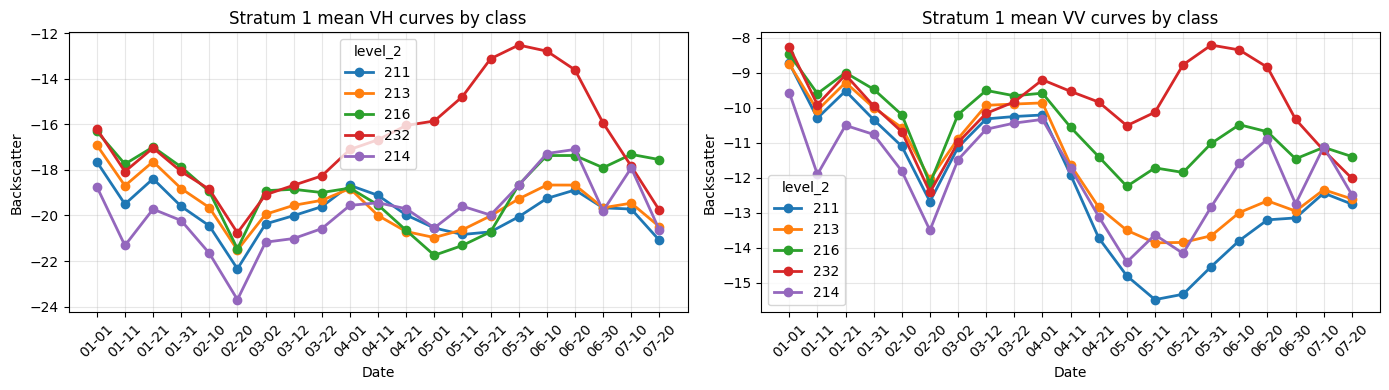

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
x_labels = [f"{date[4:6]}-{date[6:8]}" for date in dates]
top_classes = pd.Series(y_train).value_counts().head(5).index.tolist()

for cls in top_classes:
    cls_curves = X_train[y_train == cls]
    axes[0].plot(range(len(dates)), cls_curves[:, :, 0].mean(axis=0), marker="o", linewidth=2, label=str(cls))
    axes[1].plot(range(len(dates)), cls_curves[:, :, 1].mean(axis=0), marker="o", linewidth=2, label=str(cls))

axes[0].set_title("Stratum 1 mean VH curves by class")
axes[1].set_title("Stratum 1 mean VV curves by class")

for ax in axes:
    ax.set_xticks(range(len(dates)))
    ax.set_xticklabels(x_labels, rotation=45)
    ax.set_xlabel("Date")
    ax.set_ylabel("Backscatter")
    ax.grid(True, alpha=0.3)
    ax.legend(title="level_2")

fig.tight_layout()
plt.show()
